In [3]:
# Install required libraries
!pip install transformers torch pillow matplotlib

In [4]:
# Import libraries
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel

In [5]:
# Load CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

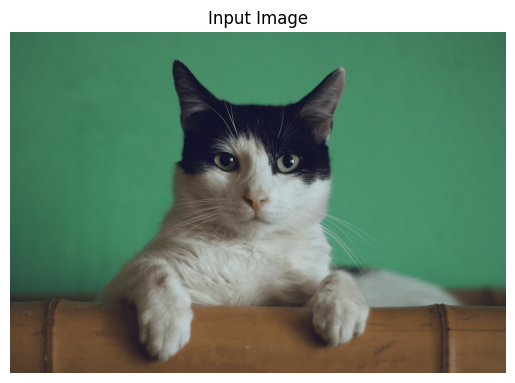

In [7]:
# Load image
import requests
from io import BytesIO

# Download a sample image
image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/cat.png"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))

plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [8]:
# Candidate captions
captions = [
    "a dog running in the park",
    "a group of people sitting at a table",
    "a cat sitting on a sofa",
    "a car parked on the street",
    "a beautiful mountain landscape"
]

In [9]:
# Process image and text together
inputs = processor(
    text=captions,
    images=image,
    return_tensors="pt",
    padding=True
)

In [10]:
# Get similarity scores
with torch.no_grad():
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)

In [11]:
# Find best caption
best_caption_index = probs.argmax().item()
best_caption = captions[best_caption_index]

print("Generated Caption:", best_caption)

Generated Caption: a cat sitting on a sofa
